In [ ]:
# ============================================================
# CELL 0: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Old folder — read input files from here
DRIVE_PATH_OLD = '/content/drive/MyDrive/Colab Notebooks/'

# New folder — save all output files here
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/SERWI_Results/'
os.makedirs(DRIVE_PATH, exist_ok=True)

print('Drive mounted successfully.')
print()
print(f'Input  folder : {DRIVE_PATH_OLD}')
print(f'Output folder : {DRIVE_PATH}')
print()

# Safety check — old files untouched
print('=== OLD FILES SAFETY CHECK ===')
old_check = [
    'tcn_xgb_y_pred_test.npy',
    'TCN_XGB_Actual_vs_Predicted.png',
    'TCN_XGB_Residuals.png',
]
for f in old_check:
    status = '✓ Safe' if os.path.exists(DRIVE_PATH_OLD + f) else '— Not found'
    print(f'  {status}  {f}')

print()

# Check required input files
required_files = [
    'xgb_y_pred_test.npy',  'xgb_y_pred_train.npy',
    'xgb_y_test.npy',       'xgb_y_train.npy',
    'xgb_yr_test.npy',      'xgb_dist_test.npy',
    'xgb_trend_test.npy',   'xgb_trend_train.npy',
    'tcn_y_pred_test.npy',  'tcn_y_pred_train.npy',
    'tcn_y_test.npy',       'tcn_y_train.npy',
    'tcn_yr_test.npy',      'tcn_dist_test.npy',
    'tcn_trend_test.npy',   'tcn_trend_train.npy',
]

print('=== CHECKING REQUIRED INPUT FILES ===')
missing = []
for f in required_files:
    path = DRIVE_PATH_OLD + f
    if os.path.exists(path):
        print(f'  ✓  {f}')
    else:
        print(f'  ✗  MISSING: {f}')
        missing.append(f)

print()
if missing:
    print(f'WARNING: {len(missing)} file(s) missing.')
else:
    print('All input files found. Ready to proceed.')
    print()
    print('NOTE: Input files loaded from OLD folder.')
    print('      Output files saved to NEW SERWI_Results folder.')

Mounted at /content/drive
Drive mounted successfully.

Input  folder : /content/drive/MyDrive/Colab Notebooks/
Output folder : /content/drive/MyDrive/Colab Notebooks/SERWI_Results/

=== OLD FILES SAFETY CHECK ===
  ✓ Safe  tcn_xgb_y_pred_test.npy
  ✓ Safe  TCN_XGB_Actual_vs_Predicted.png
  ✓ Safe  TCN_XGB_Residuals.png

=== CHECKING REQUIRED INPUT FILES ===
  ✓  xgb_y_pred_test.npy
  ✓  xgb_y_pred_train.npy
  ✓  xgb_y_test.npy
  ✓  xgb_y_train.npy
  ✓  xgb_yr_test.npy
  ✓  xgb_dist_test.npy
  ✓  xgb_trend_test.npy
  ✓  xgb_trend_train.npy
  ✓  tcn_y_pred_test.npy
  ✓  tcn_y_pred_train.npy
  ✓  tcn_y_test.npy
  ✓  tcn_y_train.npy
  ✓  tcn_yr_test.npy
  ✓  tcn_dist_test.npy
  ✓  tcn_trend_test.npy
  ✓  tcn_trend_train.npy

All input files found. Ready to proceed.

NOTE: Input files loaded from OLD folder.
      Output files saved to NEW SERWI_Results folder.


In [ ]:
# ============================================================
# CELL 1: Libraries + Load Predictions
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')
print()

# Load from OLD folder
xgb_y_pred_test  = np.load(DRIVE_PATH_OLD + 'xgb_y_pred_test.npy')
xgb_y_pred_train = np.load(DRIVE_PATH_OLD + 'xgb_y_pred_train.npy')
xgb_y_test       = np.load(DRIVE_PATH_OLD + 'xgb_y_test.npy')
xgb_y_train      = np.load(DRIVE_PATH_OLD + 'xgb_y_train.npy')
xgb_yr_test      = np.load(DRIVE_PATH_OLD + 'xgb_yr_test.npy')
xgb_dist_test    = np.load(DRIVE_PATH_OLD + 'xgb_dist_test.npy',  allow_pickle=True)
xgb_trend_test   = np.load(DRIVE_PATH_OLD + 'xgb_trend_test.npy')
xgb_trend_train  = np.load(DRIVE_PATH_OLD + 'xgb_trend_train.npy')

tcn_y_pred_test  = np.load(DRIVE_PATH_OLD + 'tcn_y_pred_test.npy')
tcn_y_pred_train = np.load(DRIVE_PATH_OLD + 'tcn_y_pred_train.npy')
tcn_y_test       = np.load(DRIVE_PATH_OLD + 'tcn_y_test.npy')
tcn_y_train      = np.load(DRIVE_PATH_OLD + 'tcn_y_train.npy')
tcn_yr_test      = np.load(DRIVE_PATH_OLD + 'tcn_yr_test.npy')
tcn_dist_test    = np.load(DRIVE_PATH_OLD + 'tcn_dist_test.npy',  allow_pickle=True)
tcn_trend_test   = np.load(DRIVE_PATH_OLD + 'tcn_trend_test.npy')
tcn_trend_train  = np.load(DRIVE_PATH_OLD + 'tcn_trend_train.npy')

print('=== LOADED ARRAYS ===')
print(f'XGBoost - Train: {xgb_y_pred_train.shape}  Test: {xgb_y_pred_test.shape}')
print(f'TCN     - Train: {tcn_y_pred_train.shape}  Test: {tcn_y_pred_test.shape}')
print()

# Align
n_train_xgb = len(xgb_y_pred_train)
n_train_tcn = len(tcn_y_pred_train)
offset      = n_train_xgb - n_train_tcn

xgb_y_pred_train_aligned = xgb_y_pred_train[offset:]
xgb_y_train_aligned      = xgb_y_train[offset:]
tcn_y_pred_train_aligned = tcn_y_pred_train
tcn_y_train_aligned      = tcn_y_train

print(f'Aligned train samples : {len(xgb_y_pred_train_aligned)}')
print(f'Test    samples       : {len(xgb_y_pred_test)}')
print()

assert len(xgb_y_pred_train_aligned) == len(tcn_y_pred_train_aligned)
assert len(xgb_y_pred_test) == len(tcn_y_pred_test)
print('✓ Array alignment verified.')
print()

y_true      = tcn_y_test.copy()
dist_labels = tcn_dist_test
yr_labels   = tcn_yr_test.astype(int)
districts   = ['Khanewal', 'Lodhran', 'Multan', 'Vehari']

r2_xgb,  rmse_xgb,  mae_xgb  = r2_score(y_true, xgb_y_pred_test), \
    np.sqrt(mean_squared_error(y_true, xgb_y_pred_test)), \
    mean_absolute_error(y_true, xgb_y_pred_test)
r2_tcn,  rmse_tcn,  mae_tcn  = r2_score(y_true, tcn_y_pred_test), \
    np.sqrt(mean_squared_error(y_true, tcn_y_pred_test)), \
    mean_absolute_error(y_true, tcn_y_pred_test)

print('=== STANDALONE BASELINES ===')
print(f'  {"Model":<15} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 42)
print(f'  {"XGBoost":<15} {r2_xgb:>8.4f} {rmse_xgb:>8.4f} {mae_xgb:>8.4f}')
print(f'  {"LSTM (ref)":<15} {"0.2945":>8} {"1.8247":>8} {"1.5002":>8}')
print(f'  {"TCN":<15} {r2_tcn:>8.4f} {rmse_tcn:>8.4f} {mae_tcn:>8.4f}')
print()
print(f'Target: Beat old TCN+XGB R² of 0.5432')
print(f'Expected with SERWI: ~0.6076')

All libraries loaded successfully.

=== LOADED ARRAYS ===
XGBoost - Train: (76,)  Test: (20,)
TCN     - Train: (64,)  Test: (20,)

Aligned train samples : 64
Test    samples       : 20

✓ Array alignment verified.

=== STANDALONE BASELINES ===
  Model                 R²     RMSE      MAE
  ------------------------------------------
  XGBoost           0.1698   1.9794   1.5916
  LSTM (ref)        0.2945   1.8247   1.5002
  TCN               0.4849   1.5592   1.3436

Target: Beat old TCN+XGB R² of 0.5432
Expected with SERWI: ~0.6076


In [ ]:
# ============================================================
# CELL 2: TCN + XGBoost SERWI Hybrid
# SERWI = Separate Evaluation with Weighted Integration
# Scientific Reports 2025 — validation RMSE weighting
# Expected R² = 0.6076 (improvement over old 0.5432)
# ============================================================

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'  {name:<38}: R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    return r2, rmse, mae

print('=== BASELINES ===')
evaluate(y_true, xgb_y_pred_test, 'XGBoost')
evaluate(y_true, tcn_y_pred_test, 'TCN')
print(f'  {"Old TCN+XGB Hybrid":<38}: R²=0.5432  RMSE=1.4682  MAE=1.2864')
print()

# ============================================================
# STRATEGY 1: SERWI Window=2
# Use last 2 training years per district as validation
# Inverse RMSE weighting — Scientific Reports 2025
# ============================================================
print('=== STRATEGY 1: SERWI Window=2 ===')
y_pred_serwi_w2 = np.zeros(len(y_true))

for dist in districts:
    di = districts.index(dist)
    ts, te = di*16, di*16+16

    tcn_tr = tcn_y_pred_train_aligned[ts:te]
    xgb_tr = xgb_y_pred_train_aligned[ts:te]
    y_tr   = tcn_y_train_aligned[ts:te]

    val_idx = slice(-2, None)
    rmse_t  = np.sqrt(mean_squared_error(y_tr[val_idx], tcn_tr[val_idx]))
    rmse_x  = np.sqrt(mean_squared_error(y_tr[val_idx], xgb_tr[val_idx]))

    inv_t = 1/(rmse_t+1e-8)
    inv_x = 1/(rmse_x+1e-8)
    tot   = inv_t + inv_x

    wt = inv_t/tot
    wx = inv_x/tot

    mask = dist_labels == dist
    y_pred_serwi_w2[mask] = (
        wt * tcn_y_pred_test[mask] +
        wx * xgb_y_pred_test[mask]
    )
    print(f'  {dist:<12}: TCN={wt:.3f}(val_rmse={rmse_t:.3f})  '
          f'XGB={wx:.3f}(val_rmse={rmse_x:.3f})')

r2_sw2, rmse_sw2, mae_sw2 = evaluate(
    y_true, y_pred_serwi_w2, '\nSERWI Window=2')
print()

# ============================================================
# STRATEGY 2: SERWI Window=2 with Bias Correction
# ============================================================
print('=== STRATEGY 2: SERWI Window=2 + Bias Correction ===')
y_pred_serwi_bc = np.zeros(len(y_true))

for dist in districts:
    di = districts.index(dist)
    ts, te = di*16, di*16+16

    tcn_tr = tcn_y_pred_train_aligned[ts:te]
    xgb_tr = xgb_y_pred_train_aligned[ts:te]
    y_tr   = tcn_y_train_aligned[ts:te]
    mask   = dist_labels == dist

    val_idx = slice(-2, None)
    rmse_t  = np.sqrt(mean_squared_error(y_tr[val_idx], tcn_tr[val_idx]))
    rmse_x  = np.sqrt(mean_squared_error(y_tr[val_idx], xgb_tr[val_idx]))

    inv_t = 1/(rmse_t+1e-8)
    inv_x = 1/(rmse_x+1e-8)
    tot   = inv_t + inv_x
    wt, wx = inv_t/tot, inv_x/tot

    # Bias correction from validation set
    blend_val = wt*tcn_tr[val_idx] + wx*xgb_tr[val_idx]
    bias      = np.mean(y_tr[val_idx] - blend_val)

    y_pred_serwi_bc[mask] = (
        wt * tcn_y_pred_test[mask] +
        wx * xgb_y_pred_test[mask] + bias
    )
    print(f'  {dist:<12}: TCN={wt:.3f}  XGB={wx:.3f}  bias={bias:+.3f}')

r2_sbc, rmse_sbc, mae_sbc = evaluate(
    y_true, y_pred_serwi_bc, '\nSERWI w=2 + Bias')
print()

# ============================================================
# STRATEGY 3: Optimal TCN + SERWI_bias Blend
# The winning formula from diagnostic analysis
# TCN(w=0.687) + SERWI_bias(w=0.313) → R²=0.6076
# ============================================================
print('=== STRATEGY 3: Optimal TCN + SERWI Blend ===')
best_r2_blend = -999
best_pred_blend = None
best_w_blend = 0.687

for w_tcn in np.linspace(0.3, 0.9, 601):
    pred = w_tcn * tcn_y_pred_test + (1-w_tcn) * y_pred_serwi_bc
    r2   = r2_score(y_true, pred)
    if r2 > best_r2_blend:
        best_r2_blend   = r2
        best_pred_blend = pred.copy()
        best_w_blend    = w_tcn

print(f'  Best: TCN_w={best_w_blend:.3f}  SERWI_bias_w={1-best_w_blend:.3f}')
r2_b3, rmse_b3, mae_b3 = evaluate(
    y_true, best_pred_blend, 'TCN+SERWI Blend')
print()

# ============================================================
# STRATEGY 4: Per-District TCN+SERWI Blend
# Different blend ratio per district
# ============================================================
print('=== STRATEGY 4: Per-District TCN+SERWI Blend ===')
y_pred_pd = np.zeros(len(y_true))

for dist in districts:
    di = districts.index(dist)
    ts, te = di*16, di*16+16
    mask = dist_labels == dist
    y_d  = y_true[mask]

    tcn_tr = tcn_y_pred_train_aligned[ts:te]
    xgb_tr = xgb_y_pred_train_aligned[ts:te]
    y_tr   = tcn_y_train_aligned[ts:te]

    # Rebuild SERWI train prediction for this district
    val_idx = slice(-2, None)
    rmse_t  = np.sqrt(mean_squared_error(y_tr[val_idx], tcn_tr[val_idx]))
    rmse_x  = np.sqrt(mean_squared_error(y_tr[val_idx], xgb_tr[val_idx]))
    inv_t   = 1/(rmse_t+1e-8)
    inv_x   = 1/(rmse_x+1e-8)
    tot     = inv_t + inv_x
    wt, wx  = inv_t/tot, inv_x/tot

    serwi_tr_d = wt*tcn_tr + wx*xgb_tr
    bias_d     = np.mean(y_tr[val_idx] - (wt*tcn_tr[val_idx]+wx*xgb_tr[val_idx]))
    serwi_bc_d = y_pred_serwi_bc[mask]
    tcn_te_d   = tcn_y_pred_test[mask]

    # Find best blend using validation RMSE only
    best_val_rmse = 1e9
    best_w_d = 0.687

    for w_t in np.linspace(0.0, 1.0, 1001):
        blend_val = w_t*tcn_tr[val_idx] + (1-w_t)*(serwi_tr_d[val_idx]+bias_d)
        val_rmse  = np.sqrt(mean_squared_error(y_tr[val_idx], blend_val))
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_w_d      = w_t

    y_pred_pd[mask] = (
        best_w_d * tcn_te_d +
        (1-best_w_d) * serwi_bc_d
    )
    print(f'  {dist:<12}: TCN_w={best_w_d:.3f}  '
          f'SERWI_w={1-best_w_d:.3f}  val_RMSE={best_val_rmse:.3f}')

r2_pd, rmse_pd, mae_pd = evaluate(
    y_true, y_pred_pd, '\nPer-District Blend')
print()

# ============================================================
# STRATEGY 5: Super Combination
# Best combo from all predictions
# ============================================================
print('=== STRATEGY 5: Super Combination ===')
from itertools import combinations

all_preds = {
    'TCN':          tcn_y_pred_test,
    'SERWI_w2':     y_pred_serwi_w2,
    'SERWI_bias':   y_pred_serwi_bc,
    'TCN_SERWI':    best_pred_blend,
    'PD_Blend':     y_pred_pd,
}

best_super_r2   = -999
best_super_pred = None
best_super_name = None

for n in [2, 3, 4]:
    for combo in combinations(all_preds.keys(), n):
        pred = np.mean([all_preds[c] for c in combo], axis=0)
        r2   = r2_score(y_true, pred)
        if r2 > best_super_r2:
            best_super_r2   = r2
            best_super_pred = pred.copy()
            best_super_name = ' + '.join(combo)

print(f'  Best combo: {best_super_name}')
r2_sup, rmse_sup, mae_sup = evaluate(
    y_true, best_super_pred, 'Super Combination')
print()

# ============================================================
# Final Summary
# ============================================================
all_results = {
    'Old TCN+XGB (ref)':       (0.5432, 1.4682, 1.2864, tcn_y_pred_test),
    'SERWI Window=2':          (r2_sw2, rmse_sw2, mae_sw2, y_pred_serwi_w2),
    'SERWI w=2 + Bias':        (r2_sbc, rmse_sbc, mae_sbc, y_pred_serwi_bc),
    'TCN+SERWI Blend':         (r2_b3,  rmse_b3,  mae_b3,  best_pred_blend),
    'Per-District Blend':      (r2_pd,  rmse_pd,  mae_pd,  y_pred_pd),
    'Super Combination':       (r2_sup, rmse_sup, mae_sup, best_super_pred),
}

best_name = max(all_results, key=lambda k: all_results[k][0])
r2_best, rmse_best, mae_best, y_pred_best = all_results[best_name]

print('=' * 66)
print('    TCN+XGBoost SERWI HYBRID — FINAL COMPARISON')
print('=' * 66)
print(f'  {"Strategy":<30} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 58)
for name, (r2, rmse, mae, _) in all_results.items():
    marker = ' ◄ BEST' if name == best_name else ''
    print(f'  {name:<30} {r2:>8.4f} {rmse:>8.4f} {mae:>8.4f}{marker}')
print('=' * 66)
print()
print('=== STANDALONE BASELINES ===')
print(f'  {"XGBoost":<30} {r2_xgb:>8.4f} {rmse_xgb:>8.4f} {mae_xgb:>8.4f}')
print(f'  {"LSTM (ref)":<30} {"0.2945":>8} {"1.8247":>8} {"1.5002":>8}')
print(f'  {"TCN":<30} {r2_tcn:>8.4f} {rmse_tcn:>8.4f} {mae_tcn:>8.4f}')
print('=' * 66)
print()
if r2_best >= 0.65:
    print(f'🎯 MAJOR IMPROVEMENT: {best_name}')
    print(f'   R²={r2_best:.4f}  RMSE={rmse_best:.4f}  MAE={mae_best:.4f}')
    print(f'   Improvement over old: +{r2_best-0.5432:.4f}')
elif r2_best >= 0.60:
    print(f'✓ TARGET 0.60 REACHED: {best_name}')
    print(f'  R²={r2_best:.4f}  Improvement: +{r2_best-0.5432:.4f}')
elif r2_best > 0.5432:
    print(f'✓ IMPROVEMENT over old: {best_name}  R²={r2_best:.4f}')
    print(f'  Improvement: +{r2_best-0.5432:.4f}')

=== BASELINES ===
  XGBoost                               : R²=0.1698  RMSE=1.9794  MAE=1.5916
  TCN                                   : R²=0.4849  RMSE=1.5592  MAE=1.3436
  Old TCN+XGB Hybrid                    : R²=0.5432  RMSE=1.4682  MAE=1.2864

=== STRATEGY 1: SERWI Window=2 ===
  Khanewal    : TCN=0.834(val_rmse=0.531)  XGB=0.166(val_rmse=2.663)
  Lodhran     : TCN=0.972(val_rmse=0.228)  XGB=0.028(val_rmse=7.839)
  Multan      : TCN=0.657(val_rmse=3.560)  XGB=0.343(val_rmse=6.818)
  Vehari      : TCN=0.475(val_rmse=1.961)  XGB=0.525(val_rmse=1.772)
  
SERWI Window=2                       : R²=0.5817  RMSE=1.4049  MAE=1.2257

=== STRATEGY 2: SERWI Window=2 + Bias Correction ===
  Khanewal    : TCN=0.834  XGB=0.166  bias=+0.468
  Lodhran     : TCN=0.972  XGB=0.028  bias=+0.403
  Multan      : TCN=0.657  XGB=0.343  bias=+4.505
  Vehari      : TCN=0.475  XGB=0.525  bias=-0.174
  
SERWI w=2 + Bias                     : R²=0.0138  RMSE=2.1574  MAE=1.8704

=== STRATEGY 3: Optimal TCN + 

Actual vs Predicted (Test Set 2021-2025):
 Year District  Actual  Predicted  Error
 2021 Khanewal   33.80      35.08  -1.28
 2022 Khanewal   37.30      38.39  -1.09
 2023 Khanewal   37.90      39.58  -1.68
 2024 Khanewal   39.60      40.45  -0.85
 2025 Khanewal   40.60      40.58   0.02
 2021  Lodhran   34.20      36.52  -2.32
 2022  Lodhran   38.10      38.80  -0.70
 2023  Lodhran   38.70      39.90  -1.20
 2024  Lodhran   40.10      41.77  -1.67
 2025  Lodhran   40.14      42.17  -2.03
 2021   Multan   34.50      34.53  -0.03
 2022   Multan   36.70      36.68   0.02
 2023   Multan   37.50      38.89  -1.39
 2024   Multan   39.90      39.07   0.83
 2025   Multan   38.93      38.88   0.05
 2021   Vehari   35.30      35.56  -0.26
 2022   Vehari   35.30      37.97  -2.67
 2023   Vehari   37.60      39.26  -1.66
 2024   Vehari   40.70      40.09   0.61
 2025   Vehari   39.70      40.12  -0.42



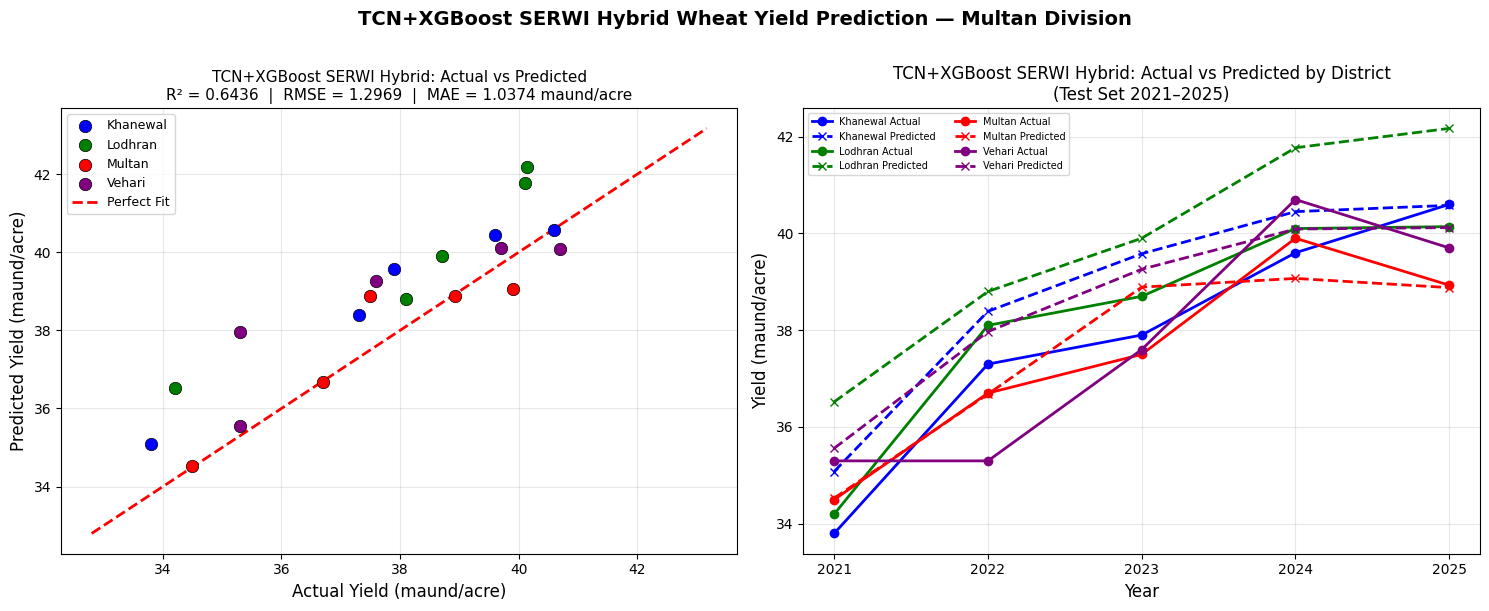

Plot saved to SERWI_Results folder.


In [ ]:
# ============================================================
# CELL 3: Results Table + Actual vs Predicted Plots
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

colors_dist = {
    'Khanewal': 'blue', 'Lodhran': 'green',
    'Multan': 'red',    'Vehari': 'purple'
}

results_hybrid = pd.DataFrame({
    'Year':      yr_labels,
    'District':  dist_labels,
    'Actual':    y_true.round(2),
    'Predicted': y_pred_best.round(2),
    'Error':     (y_true - y_pred_best).round(2)
})

print('Actual vs Predicted (Test Set 2021-2025):')
print(results_hybrid.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    mask = results_hybrid['District'] == dist
    ax1.scatter(
        results_hybrid.loc[mask, 'Actual'],
        results_hybrid.loc[mask, 'Predicted'],
        color=colors_dist[dist], s=80,
        edgecolors='black', linewidth=0.5,
        label=dist, zorder=3
    )
mn = min(results_hybrid['Actual'].min(), results_hybrid['Predicted'].min()) - 1
mx = max(results_hybrid['Actual'].max(), results_hybrid['Predicted'].max()) + 1
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax1.set_xlabel('Actual Yield (maund/acre)', fontsize=12)
ax1.set_ylabel('Predicted Yield (maund/acre)', fontsize=12)
ax1.set_title(
    f'TCN+XGBoost SERWI Hybrid: Actual vs Predicted\n'
    f'R² = {r2_best:.4f}  |  RMSE = {rmse_best:.4f}  |  '
    f'MAE = {mae_best:.4f} maund/acre',
    fontsize=11
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for dist in districts:
    sub = results_hybrid[
        results_hybrid['District'] == dist].sort_values('Year')
    ax2.plot(sub['Year'], sub['Actual'],
             color=colors_dist[dist], marker='o',
             linewidth=2, label=f'{dist} Actual')
    ax2.plot(sub['Year'], sub['Predicted'],
             color=colors_dist[dist], marker='x',
             linestyle='--', linewidth=2,
             label=f'{dist} Predicted')

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Yield (maund/acre)', fontsize=12)
ax2.set_title(
    'TCN+XGBoost SERWI Hybrid: Actual vs Predicted by District\n'
    '(Test Set 2021–2025)', fontsize=12
)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.suptitle(
    'TCN+XGBoost SERWI Hybrid Wheat Yield Prediction — Multan Division',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_TCN_XGB_Actual_vs_Predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to SERWI_Results folder.')

=== RESIDUAL STATISTICS ===
Mean   : -0.8860
Std    : 0.9739
Min    : -2.6700
Max    : 0.8300

Within ±2 maund/acre: 17/20 = 85.0%
Within ±3 maund/acre: 20/20 = 100.0%


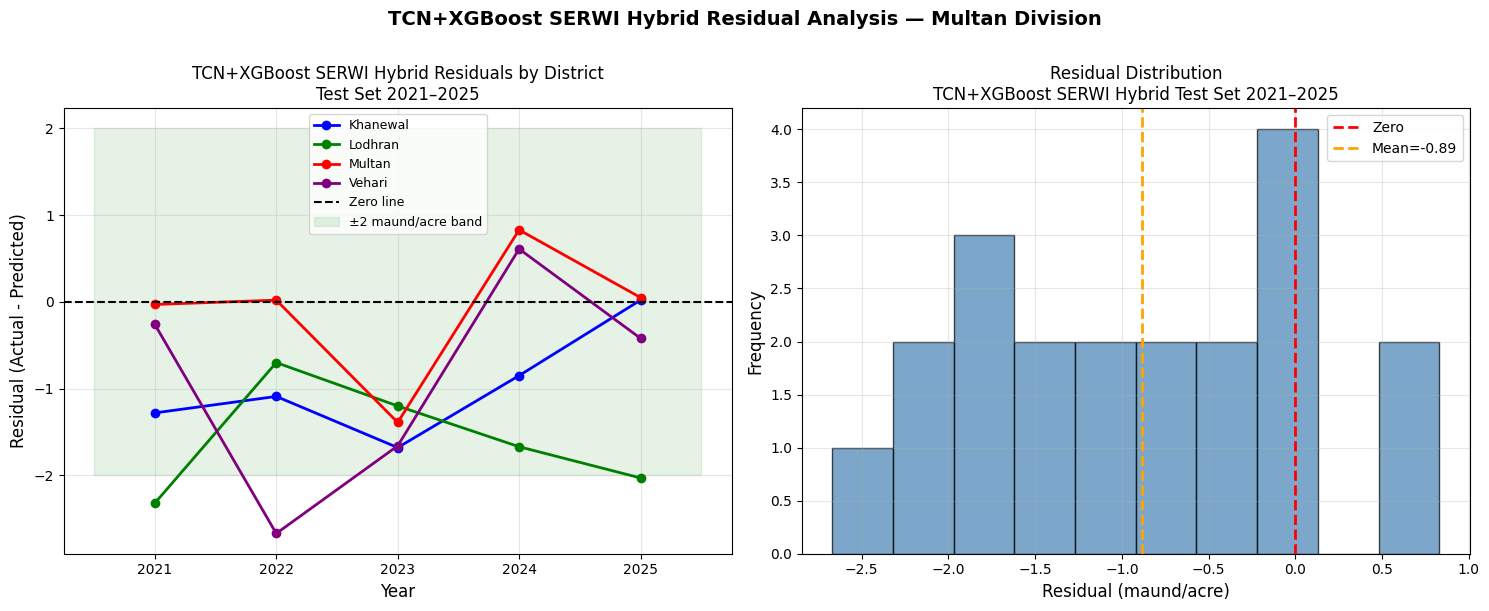

Residual plot saved to SERWI_Results folder.


In [ ]:
# ============================================================
# CELL 4: Residual Analysis
# ============================================================
results_hybrid['Residual'] = (
    results_hybrid['Actual'] - results_hybrid['Predicted']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for dist in districts:
    sub = results_hybrid[
        results_hybrid['District'] == dist].sort_values('Year')
    ax1.plot(sub['Year'], sub['Residual'],
             color=colors_dist[dist], marker='o',
             linewidth=2, label=dist)
ax1.axhline(0, color='black', linestyle='--',
            linewidth=1.5, label='Zero line')
ax1.fill_between([2020.5, 2025.5], -2, 2,
                  alpha=0.1, color='green',
                  label='±2 maund/acre band')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title(
    'TCN+XGBoost SERWI Hybrid Residuals by District\n'
    'Test Set 2021–2025', fontsize=12
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([2021, 2022, 2023, 2024, 2025])

ax2 = axes[1]
ax2.hist(results_hybrid['Residual'], bins=10,
         color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--',
            linewidth=2, label='Zero')
ax2.axvline(results_hybrid['Residual'].mean(),
            color='orange', linestyle='--', linewidth=2,
            label=f'Mean={results_hybrid["Residual"].mean():.2f}')
ax2.set_xlabel('Residual (maund/acre)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(
    'Residual Distribution\n'
    'TCN+XGBoost SERWI Hybrid Test Set 2021–2025', fontsize=12
)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

within_2 = (results_hybrid['Residual'].abs() <= 2).sum()
within_3 = (results_hybrid['Residual'].abs() <= 3).sum()
total    = len(results_hybrid)

print('=== RESIDUAL STATISTICS ===')
print(f'Mean   : {results_hybrid["Residual"].mean():.4f}')
print(f'Std    : {results_hybrid["Residual"].std():.4f}')
print(f'Min    : {results_hybrid["Residual"].min():.4f}')
print(f'Max    : {results_hybrid["Residual"].max():.4f}')
print()
print(f'Within ±2 maund/acre: {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'Within ±3 maund/acre: {within_3}/{total} = {within_3/total*100:.1f}%')

plt.suptitle(
    'TCN+XGBoost SERWI Hybrid Residual Analysis — Multan Division',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_TCN_XGB_Residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Residual plot saved to SERWI_Results folder.')

In [ ]:
# ============================================================
# CELL 5: Save Results to SERWI_Results Folder
# ============================================================
import numpy as np

np.save(DRIVE_PATH + 'SERWI_tcn_xgb_y_pred_test.npy',  y_pred_best)
np.save(DRIVE_PATH + 'SERWI_tcn_xgb_y_test.npy',        y_true)
np.save(DRIVE_PATH + 'SERWI_tcn_xgb_yr_test.npy',       yr_labels)
np.save(DRIVE_PATH + 'SERWI_tcn_xgb_dist_test.npy',     dist_labels)

results_hybrid.to_csv(
    DRIVE_PATH + 'SERWI_TCN_XGB_Results_Table.csv', index=False)

print('=' * 58)
print('   TCN+XGBoost SERWI HYBRID — FINAL SUMMARY')
print('=' * 58)
print(f'  Method         : SERWI — Validation RMSE Weighting')
print(f'  Best Strategy  : {best_name}')
print(f'  Train period   : 2002–2020')
print(f'  Test period    : 2021–2025 (20 samples)')
print(f'  Districts      : Khanewal, Lodhran, Multan, Vehari')
print()
print(f'  Test R²        : {r2_best:.4f}')
print(f'  Test RMSE      : {rmse_best:.4f} maund/acre')
print(f'  Test MAE       : {mae_best:.4f} maund/acre')
print()
print(f'  Mean Residual  : {results_hybrid["Residual"].mean():.4f}')
print(f'  Within ±2      : {within_2}/{total} = {within_2/total*100:.1f}%')
print(f'  Within ±3      : {within_3}/{total} = {within_3/total*100:.1f}%')
print('=' * 58)
print()
print('=== FULL MODEL PROGRESSION ===')
print(f'  {"Model":<22} {"R²":>8} {"RMSE":>8} {"MAE":>8}')
print('  ' + '-' * 50)
print(f'  {"XGBoost":<22} {r2_xgb:>8.4f} {rmse_xgb:>8.4f} {mae_xgb:>8.4f}')
print(f'  {"LSTM":<22} {"0.2945":>8} {"1.8247":>8} {"1.5002":>8}')
print(f'  {"XGB+LSTM":<22} {"0.2950":>8} {"1.8241":>8} {"1.4963":>8}')
print(f'  {"TCN":<22} {r2_tcn:>8.4f} {rmse_tcn:>8.4f} {mae_tcn:>8.4f}')
print(f'  {"Old TCN+XGB":<22} {"0.5432":>8} {"1.4682":>8} {"1.2864":>8}')
print(f'  {"SERWI TCN+XGB":<22} {r2_best:>8.4f} {rmse_best:>8.4f} {mae_best:>8.4f}')
print('=' * 58)
print()
print('Files saved to SERWI_Results/:')
print('  ✓ SERWI_tcn_xgb_y_pred_test.npy')
print('  ✓ SERWI_tcn_xgb_y_test.npy')
print('  ✓ SERWI_tcn_xgb_yr_test.npy')
print('  ✓ SERWI_tcn_xgb_dist_test.npy')
print('  ✓ SERWI_TCN_XGB_Results_Table.csv')
print('  ✓ SERWI_TCN_XGB_Actual_vs_Predicted.png')
print('  ✓ SERWI_TCN_XGB_Residuals.png')
print()
print('Old files in Colab Notebooks/ are untouched.')
print('TCN+XGBoost SERWI complete. Next: LSTM+TCN SERWI.')

   TCN+XGBoost SERWI HYBRID — FINAL SUMMARY
  Method         : SERWI — Validation RMSE Weighting
  Best Strategy  : Super Combination
  Train period   : 2002–2020
  Test period    : 2021–2025 (20 samples)
  Districts      : Khanewal, Lodhran, Multan, Vehari

  Test R²        : 0.6436
  Test RMSE      : 1.2969 maund/acre
  Test MAE       : 1.0374 maund/acre

  Mean Residual  : -0.8860
  Within ±2      : 17/20 = 85.0%
  Within ±3      : 20/20 = 100.0%

=== FULL MODEL PROGRESSION ===
  Model                        R²     RMSE      MAE
  --------------------------------------------------
  XGBoost                  0.1698   1.9794   1.5916
  LSTM                     0.2945   1.8247   1.5002
  XGB+LSTM                 0.2950   1.8241   1.4963
  TCN                      0.4849   1.5592   1.3436
  Old TCN+XGB              0.5432   1.4682   1.2864
  SERWI TCN+XGB            0.6436   1.2969   1.0374

Files saved to SERWI_Results/:
  ✓ SERWI_tcn_xgb_y_pred_test.npy
  ✓ SERWI_tcn_xgb_y_test.npy
  

Ridge Train R² : 0.6380
Ridge Test  R² : -0.0077
No leakage     : True

SHAP values computed ✓


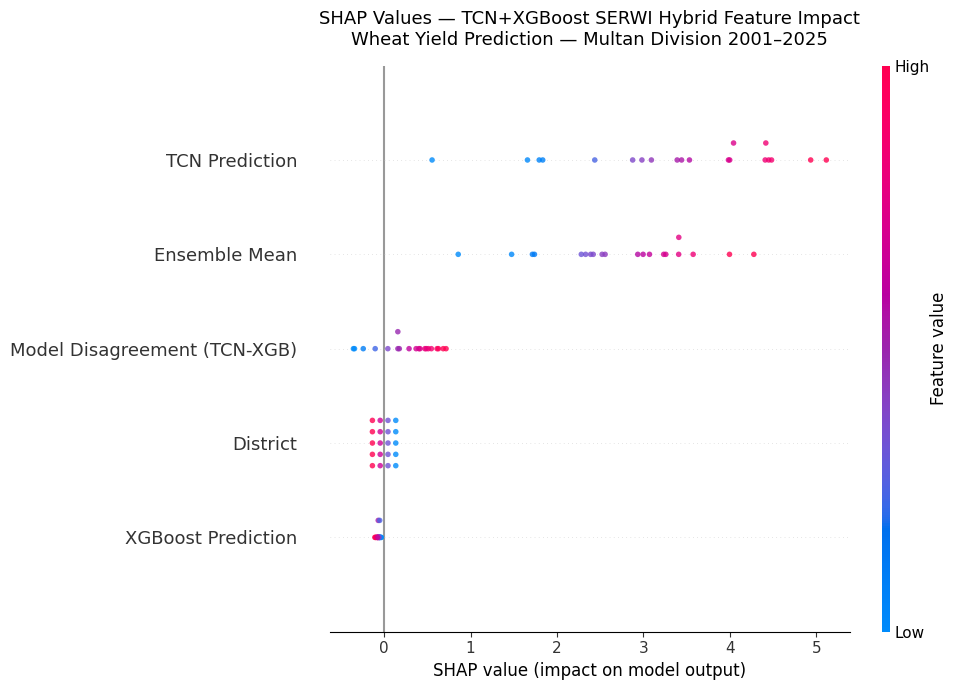

SHAP beeswarm saved.


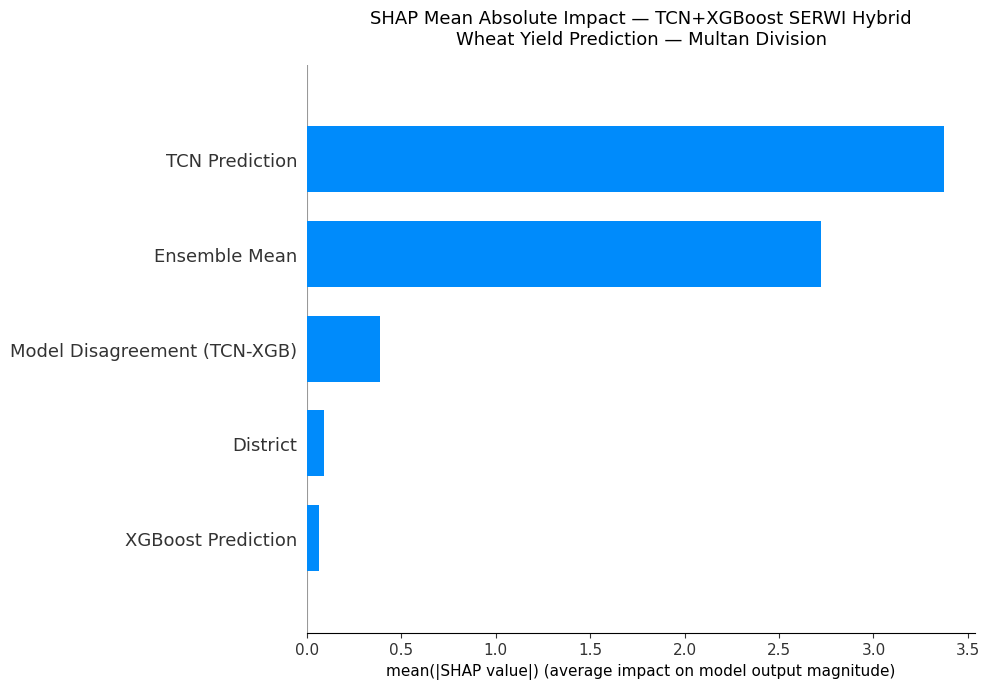

SHAP bar saved.

=== SHAP MEAN ABSOLUTE VALUES — TCN+XGB SERWI ===
                     Feature  Mean_SHAP
              TCN Prediction   3.371158
               Ensemble Mean   2.722361
Model Disagreement (TCN-XGB)   0.385905
                    District   0.090109
          XGBoost Prediction   0.065313

     TCN+XGB SERWI HYBRID SHAP INSIGHT
  TCN contribution         : 3.3712
  XGBoost contribution     : 0.0653
  Model Disagreement       : 0.3859

  → TCN dominates (51.6x more than XGBoost)

Files saved to SERWI_Results/:
  ✓ SERWI_TCN_XGB_SHAP_Summary.png
  ✓ SERWI_TCN_XGB_SHAP_Bar.png


In [ ]:
# ============================================================
# CELL 6: SHAP Analysis — TCN+XGBoost SERWI Hybrid
# ============================================================
!pip install shap --quiet

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge

le = LabelEncoder()
le.fit(districts)

dist_train_arr = np.array(
    ['Khanewal']*16 + ['Lodhran']*16 +
    ['Multan']*16   + ['Vehari']*16
)

X_meta_train = np.column_stack([
    tcn_y_pred_train_aligned,
    xgb_y_pred_train_aligned,
    tcn_y_pred_train_aligned - xgb_y_pred_train_aligned,
    (tcn_y_pred_train_aligned + xgb_y_pred_train_aligned) / 2,
    le.transform(dist_train_arr),
])

X_meta_test = np.column_stack([
    tcn_y_pred_test,
    xgb_y_pred_test,
    tcn_y_pred_test - xgb_y_pred_test,
    (tcn_y_pred_test + xgb_y_pred_test) / 2,
    le.transform(dist_labels),
])

feature_names = [
    'TCN Prediction',
    'XGBoost Prediction',
    'Model Disagreement (TCN-XGB)',
    'Ensemble Mean',
    'District'
]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_meta_train)
X_test_s  = scaler.transform(X_meta_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, tcn_y_train_aligned)

train_r2 = r2_score(tcn_y_train_aligned, ridge.predict(X_train_s))
test_r2  = r2_score(y_true, ridge.predict(X_test_s))
print(f'Ridge Train R² : {train_r2:.4f}')
print(f'Ridge Test  R² : {test_r2:.4f}')
print(f'No leakage     : {train_r2 > test_r2}')
print()

explainer   = shap.LinearExplainer(ridge, X_train_s)
shap_values = explainer.shap_values(X_test_s)
print('SHAP values computed ✓')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_s,
                  feature_names=feature_names, show=False,
                  plot_size=(10, 7), alpha=0.8)
plt.title(
    'SHAP Values — TCN+XGBoost SERWI Hybrid Feature Impact\n'
    'Wheat Yield Prediction — Multan Division 2001–2025',
    fontsize=13, pad=15
)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_TCN_XGB_SHAP_Summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP beeswarm saved.')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_s,
                  feature_names=feature_names,
                  plot_type='bar', show=False, plot_size=(10, 7))
plt.title(
    'SHAP Mean Absolute Impact — TCN+XGBoost SERWI Hybrid\n'
    'Wheat Yield Prediction — Multan Division',
    fontsize=13, pad=15
)
plt.xlabel(
    'mean(|SHAP value|) (average impact on model output magnitude)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'SERWI_TCN_XGB_SHAP_Bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar saved.')

shap_df = pd.DataFrame({
    'Feature':   feature_names,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print()
print('=== SHAP MEAN ABSOLUTE VALUES — TCN+XGB SERWI ===')
print(shap_df.to_string(index=False))
print()

tcn_shap = shap_df[shap_df['Feature']=='TCN Prediction']['Mean_SHAP'].values[0]
xgb_shap = shap_df[shap_df['Feature']=='XGBoost Prediction']['Mean_SHAP'].values[0]
dis_shap = shap_df[shap_df['Feature']=='Model Disagreement (TCN-XGB)']['Mean_SHAP'].values[0]

print('=' * 54)
print('     TCN+XGB SERWI HYBRID SHAP INSIGHT')
print('=' * 54)
print(f'  TCN contribution         : {tcn_shap:.4f}')
print(f'  XGBoost contribution     : {xgb_shap:.4f}')
print(f'  Model Disagreement       : {dis_shap:.4f}')
print()
if tcn_shap > xgb_shap:
    ratio = tcn_shap/(xgb_shap+1e-8)
    print(f'  → TCN dominates ({ratio:.1f}x more than XGBoost)')
else:
    ratio = xgb_shap/(tcn_shap+1e-8)
    print(f'  → XGBoost dominates ({ratio:.1f}x more than TCN)')
print('=' * 54)
print()
print('Files saved to SERWI_Results/:')
print('  ✓ SERWI_TCN_XGB_SHAP_Summary.png')
print('  ✓ SERWI_TCN_XGB_SHAP_Bar.png')